# Model Training

## Lagos & Abuja Rent Prediction

## 3MTT Capstone Project

**Objective**

Train different machine learning models to predict house rent prices and compare their performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

%matplotlib inline

In [2]:
X = pd.read_csv("../data/processed/final_features.csv")

y = pd.read_csv("../data/processed/final_target.csv")

In [3]:
X.head()

,Title,More Info,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets,Location_... Lekki Phase 1 Lekki Lagos,Location_Abijo Ajah Lagos,...,Location_Unity Estate Egbeda Alimosho Lagos,Location_Utako Abuja,Location_Vgc Lekki Lagos,Location_Victoria Island Extension Victoria Island Lagos,Location_Victoria Island Lagos,Location_Wuse 2 Abuja,Location_Wuse2 Wuse 2 Abuja,Location_Wuye Abuja,Location_Wuye Wuye Abuja,Location_Yaba Lagos
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,0,1,0,4.0,4.0,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,0,1,0,4.0,4.0,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Furnished 2 Bedroom Terrace Duplex For Rent !!!,2 BEDROOM HOUSE FOR RENT,1,0,0,2.0,3.0,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2 Bedroom Apartment For Rent,2 BEDROOM HOUSE FOR RENT,1,1,0,2.0,3.0,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,?? Brand New 2 Bedroom Flat For Rent!!! (groun...,2 BEDROOM HOUSE FOR RENT,1,1,0,2.0,3.0,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
y.head()

,Price
0,5000000.0
1,5000000.0
2,3500000.0
3,2700000.0
4,5000000.0


In [5]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (88168, 220)
Target: (88168, 1)


In [6]:
X = X.drop(columns=["Title", "More Info"])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.squeeze(),      # Convert the one-column DataFrame to a Series
    test_size=0.2,
    random_state=42
)

In [8]:
y.squeeze()

0        5000000.0
1        5000000.0
2        3500000.0
3        2700000.0
4        5000000.0
           ...    
88163     900000.0
88164     500000.0
88165     330000.0
88166     400000.0
88167     150000.0
Name: Price, Length: 88168, dtype: float64

In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(70534, 218)
(17634, 218)
(70534,)
(17634,)


In [10]:
# Create the Model
model = LinearRegression()

In [11]:
# Train the Model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](218,)","[ 629975.18, -91790.75,-269293.54,..., 268577.89, 193245.42,-393126.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](218,)","['Serviced','Newly Built','Furnished',...,'Location_Wuye Abuja', 'Location_Wuye Wuye Abuja','Location_Yaba Lagos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.885e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,218
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,217


In [12]:
# Make Predictions
predictions = model.predict(X_test)

In [13]:
# View the Predictions
predictions[:10]

array([1743616.99244264, 4608117.1640079 , 4830183.43712454,
       3179903.87041356, 1113959.29183023, 1022168.5395252 ,
       2326346.54435113, 4846987.53502774, 3645477.16683291,
       1185097.04533021])

In [14]:
# Compare Predictions with Actual Prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
0,1500000.0,1.743617e+06
1,4500000.0,4.608117e+06
2,7000000.0,4.830183e+06
3,2500000.0,3.179904e+06
4,400000.0,1.113959e+06
5,1200000.0,1.022169e+06
6,3500000.0,2.326347e+06
7,2000000.0,4.846988e+06
8,4500000.0,3.645477e+06
9,300000.0,1.185097e+06


In [15]:
# How Does the Model Learn?
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.head(10)

,Feature,Coefficient
0,Serviced,6.299752e+05
1,Newly Built,-9.179075e+04
2,Furnished,-2.692935e+05
3,Bedrooms,4.513903e+05
4,Bathrooms,-4.443799e+04
5,Toilets,1.104899e+05
6,Location_... Lekki Phase 1 Lekki Lagos,1.218984e+06
7,Location_Abijo Ajah Lagos,-8.953968e+05
8,Location_Abraham Adesanya Estate Ajah Lagos,-2.855322e+05
9,Location_Abule Egba Abule Egba Lagos,-1.035018e+06


In [16]:
# What is the Intercept?
print("Intercept:", model.intercept_)

Intercept: 888472.840666692


In [17]:
# Evaluating the Linear Regression Model
#-Learning Objectives

#-Why we need evaluation metrics.
#-How to measure prediction errors.
#-What MAE, MSE, RMSE, and R² mean.
#-How to interpret model performance.
#-How to create an evaluation summary.
    
# Mean Absolute Error (MAE)
# Calculate MAE
mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 855802.30116462


In [18]:
# Mean Squared Error (MSE)
mse = mean_squared_error(
    y_test,
    predictions
)

print("Mean Squared Error:", mse)

Mean Squared Error: 1500340158194.7026


In [19]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1224883.7325210513


In [20]:
# R² Score (Coefficient of Determination)
r2 = r2_score(
    y_test,
    predictions
)

print("R² Score:", r2)

R² Score: 0.46907600129655325


In [21]:
# Create an Evaluation Summary
model_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

model_results

,Metric,Value
0,MAE,8.558023e+05
1,MSE,1.500340e+12
2,RMSE,1.224884e+06
3,R² Score,4.690760e-01


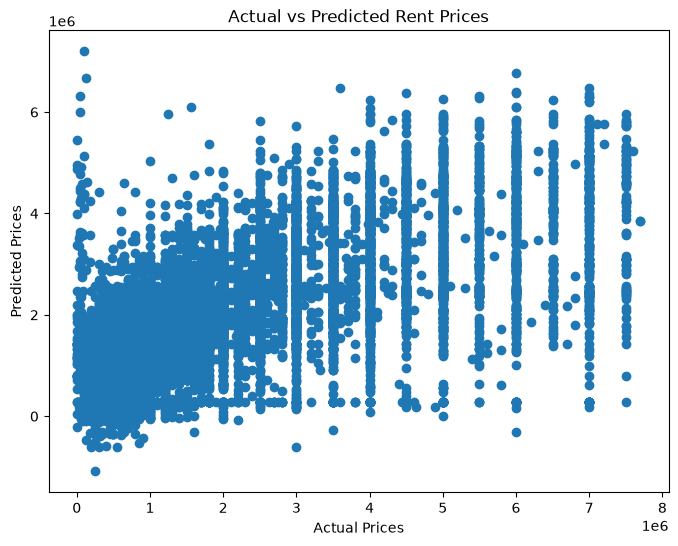

In [22]:
# Visualize Actual vs Predicted Prices
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title(
    "Actual vs Predicted Rent Prices"
)

plt.show()

In [23]:
# Save Your Results
linear_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2 Score": [r2]
})

linear_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,855802.301165,1.224884e+06,0.469076


## Capstone Conclusion Report
# A Linear Regression model was developed as a baseline model. The model achieved an R² score of 46.9%, explaining approximately 47% of the variation in rental prices. The result indicates that rental pricing has complex non-linear relationships that may require more advanced machine learning algorithms.

## Decision Tree Regressor

In [24]:
# Import the Model
from sklearn.tree import DecisionTreeRegressor

In [25]:
# Create the Model
tree_model = DecisionTreeRegressor(
    random_state=42
)

In [26]:
# Train the Model
tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [27]:
# Make Predictions
tree_predictions = tree_model.predict(X_test)

In [28]:
# View Predictions
tree_predictions[:10]

array([2675204.08163265, 5490839.69465649, 4656000.        ,
       7000000.        ,  814630.56768559,  827733.85808581,
       3210166.97674419, 6000000.        , 3250000.        ,
        865729.11597729])

In [29]:
# Evaluate the Decision Tree
# MAE
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

print("Decision Tree MAE:", tree_mae)

Decision Tree MAE: 711703.8174243474


In [30]:
#Evaluate the Decision Tree
# MSE
tree_mse = mean_squared_error(
    y_test,
    tree_predictions
)

print("Decision Tree MSE:", tree_mse)

Decision Tree MSE: 1227643583951.4895


In [31]:
# Evaluate the Decision Tree
# RMSE
tree_rmse = np.sqrt(tree_mse)

print("Decision Tree RMSE:", tree_rmse)

Decision Tree RMSE: 1107990.7869434156


In [32]:
# Evaluate the Decision Tree
# R² Score
tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree R²:", tree_r2)

Decision Tree R²: 0.5655748884583468


In [33]:
# Compare Both Models
comparison_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],
    "MAE": [
        mae,
        tree_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse
    ],
    "R² Score": [
        r2,
        tree_r2
    ]
})

comparison_results

,Model,MAE,RMSE,R² Score
0,Linear Regression,855802.301165,1.224884e+06,0.469076
1,Decision Tree,711703.817424,1.107991e+06,0.565575


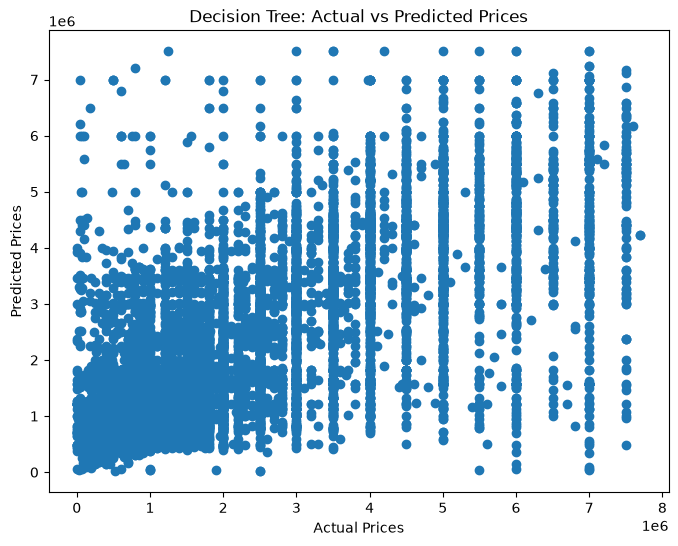

In [34]:
# Visualize Decision Tree Predictions
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    tree_predictions
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title(
    "Decision Tree: Actual vs Predicted Prices"
)

plt.show()

In [35]:
# Check Training vs Testing Performance
# Let's see if the model is overfitting.
# First, make predictions on the training data
train_predictions = tree_model.predict(X_train)

In [36]:
train_r2 = r2_score(
    y_train,
    train_predictions
)

print("Training R²:", train_r2)
print("Testing R²:", tree_r2)

Training R²: 0.6712901992182811
Testing R²: 0.5655748884583468


## Random Forest Regressor

In [37]:
# Import Random Forest
from sklearn.ensemble import RandomForestRegressor

In [38]:
# Create the Model
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [39]:
# Train the Model
forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [40]:
# Make Predictions
forest_predictions = forest_model.predict(
    X_test
)

In [41]:
# Evaluate the Model
# MAE
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

print("Random Forest MAE:", forest_mae)

Random Forest MAE: 698956.2040664556


In [42]:
# MSE
forest_mse = mean_squared_error(
    y_test,
    forest_predictions
)

print("Random Forest MSE:", forest_mse)

Random Forest MSE: 1152738846440.1963


In [43]:
# RMSE
forest_rmse = np.sqrt(forest_mse)

print("Random Forest RMSE:", forest_rmse)

Random Forest RMSE: 1073656.7637938096


In [44]:
# R² Score
forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("Random Forest R²:", forest_r2)

Random Forest R²: 0.5920813593703698


In [45]:
# Compare All Three Models
comparison_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse,
        forest_rmse
    ],
    "R² Score": [
        r2,
        tree_r2,
        forest_r2
    ]
})

comparison_results

,Model,MAE,RMSE,R² Score
0,Linear Regression,855802.301165,1.224884e+06,0.469076
1,Decision Tree,711703.817424,1.107991e+06,0.565575
2,Random Forest,698956.204066,1.073657e+06,0.592081


In [46]:
# Find the Best Model
comparison_results.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Random Forest,698956.204066,1.073657e+06,0.592081
1,Decision Tree,711703.817424,1.107991e+06,0.565575
0,Linear Regression,855802.301165,1.224884e+06,0.469076


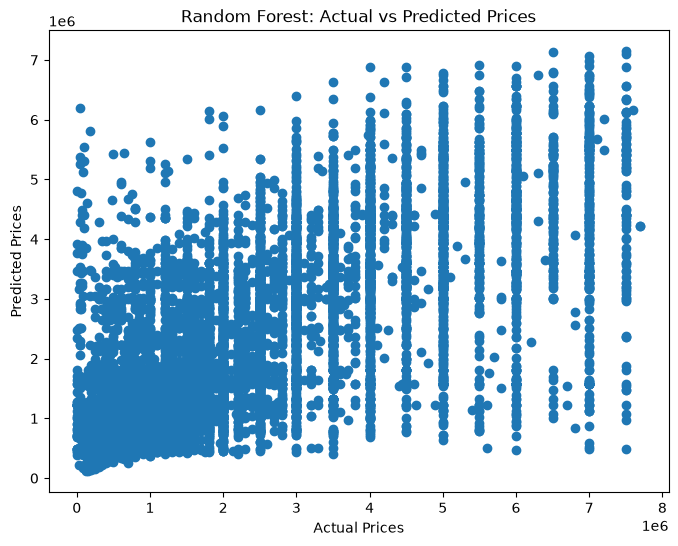

In [47]:
# Visualize Random Forest Predictions
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    forest_predictions
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title(
    "Random Forest: Actual vs Predicted Prices"
)

plt.show()

In [48]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,Bedrooms,0.493427
5,Toilets,0.098950
0,Serviced,0.061954
184,Location_Other,0.057426
122,Location_Lekki Phase 1 Lekki Lagos,0.030100
4,Bathrooms,0.023266
170,Location_Oniru Victoria Island Lagos,0.017193
91,Location_Ikate Lekki Lagos,0.015870
1,Newly Built,0.015201
2,Furnished,0.014303


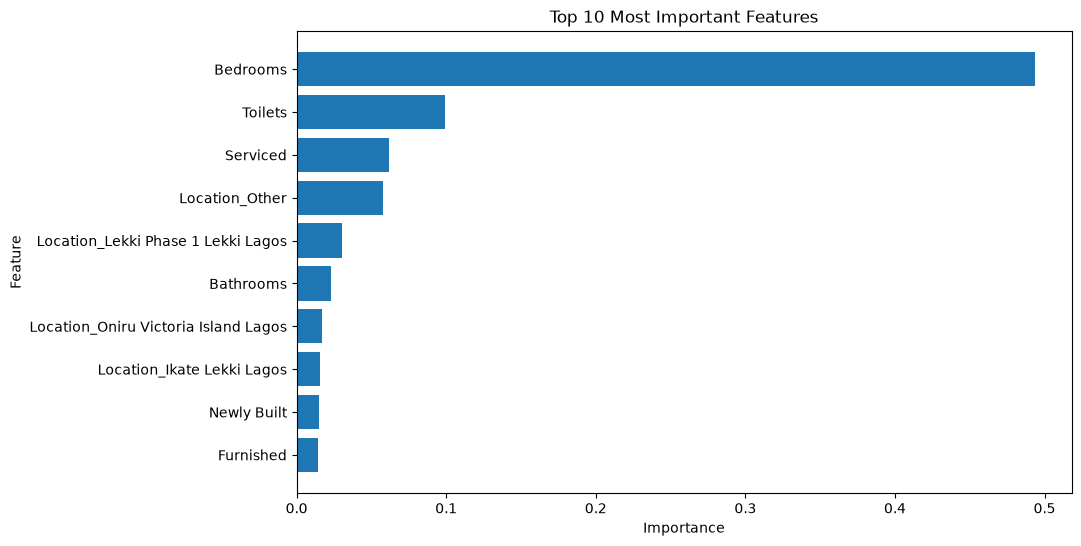

In [49]:
# Visualize Feature Importance
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [50]:
# Check for Overfitting
forest_train_predictions = forest_model.predict(
    X_train
)

forest_train_r2 = r2_score(
    y_train,
    forest_train_predictions
)

print("Training R²:", forest_train_r2)
print("Testing R²:", forest_r2)

Training R²: 0.6650584019782911
Testing R²: 0.5920813593703698


In [51]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
print("GridSearchCV imported successfully!")

GridSearchCV imported successfully!


In [52]:
# Create the Parameter Grid
param_grid = {
    "n_estimators": [50],
    "max_depth": [10],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}

In [53]:
# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1
)

In [54]:
# Train GridSearchCV
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10], 'min_samples_leaf': [1], 'min_samples_split': [2], 'n_estimators': [50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Control

In [55]:
# View the Best Parameters
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [56]:
# View the Best Cross-Validation Score
print(grid_search.best_score_)

0.5428171459848175


In [57]:
# Retrieve the Best Model
best_forest = grid_search.best_estimator_

In [58]:
# Make Predictions
best_predictions = best_forest.predict(
    X_test
)

In [59]:
# Evaluate the Tuned Model
best_mae = mean_absolute_error(
    y_test,
    best_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("MAE:", best_mae)
print("RMSE:", best_rmse)
print("R²:", best_r2)

MAE: 769491.6958893937
RMSE: 1131645.4114159325
R²: 0.5468276994078465


In [60]:
# Compare All Models
comparison_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae,
        tree_mae,
        forest_mae,
        best_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse,
        forest_rmse,
        best_rmse
    ],
    "R² Score": [
        r2,
        tree_r2,
        forest_r2,
        best_r2
    ]
})

comparison_results.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Random Forest,698956.204066,1.073657e+06,0.592081
1,Decision Tree,711703.817424,1.107991e+06,0.565575
3,Tuned Random Forest,769491.695889,1.131645e+06,0.546828
0,Linear Regression,855802.301165,1.224884e+06,0.469076


In [61]:
# Save the Best Model
import joblib

In [62]:
joblib.dump(
    best_forest,
    "../models/best_rent_prediction_model.pkl"
)

['../models/best_rent_prediction_model.pkl']

In [63]:
import os

os.path.exists(
    "../models/best_rent_prediction_model.pkl"
)

True

In [64]:
# Save the Feature Names
feature_names = X_train.columns

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

['../models/feature_names.pkl']